<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Artificial_Intelligence/blob/main/Clusteriza%C3%A7%C3%A3o/Clusteriza%C3%A7%C3%A3o_dados_sem_r%C3%B3tulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports (Bibliotecas e dados)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dados_url = "https://raw.githubusercontent.com/Mirlaa/Clusterizacao-dados-sem-rotulo/main/Dados/dados_mkt.csv"

In [ ]:
df = pd.read_csv(dados_url)


df.head(1)

,sexo,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,...,musica,rock,cabelo,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas
0,F,27,49,0,0,10,0,0,10,0,...,0,0,0,0,0,0,0,0,0,10


In [ ]:
df.head()

,sexo,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,...,musica,rock,cabelo,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas
0,F,27,49,0,0,10,0,0,10,0,...,0,0,0,0,0,0,0,0,0,10
1,F,27,41,0,0,0,0,0,0,0,...,10,20,40,0,10,0,0,0,0,10
2,F,26,1,0,0,0,0,0,10,0,...,10,0,50,0,0,0,30,0,0,0
3,M,28,32,0,50,0,0,0,0,0,...,10,10,0,0,0,0,0,0,0,0
4,M,28,18,0,0,0,0,0,0,0,...,0,0,0,0,0,0,10,0,0,0


> Os dados são referentes ao número de vezes que um assunto foi citado

#Analisando os dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12992 entries, 0 to 12991
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sexo               12992 non-null  object
 1   idade              12992 non-null  int64 
 2   numero_de_amigos   12992 non-null  int64 
 3   basquete           12992 non-null  int64 
 4   futebol_americano  12992 non-null  int64 
 5   futebol            12992 non-null  int64 
 6   softbol            12992 non-null  int64 
 7   voleibol           12992 non-null  int64 
 8   natacao            12992 non-null  int64 
 9   animacao           12992 non-null  int64 
 10  beisebol           12992 non-null  int64 
 11  tenis              12992 non-null  int64 
 12  esportes           12992 non-null  int64 
 13  fofo               12992 non-null  int64 
 14  danca              12992 non-null  int64 
 15  banda              12992 non-null  int64 
 16  marcha             12992 non-null  int64

>  coluna sexo está como object(string) é necessário analisar com mais profundidade

In [ ]:
df['sexo'].unique()

array(['F', 'M', 'NE'], dtype=object)

>  Para normalizar(int) vamos usar o one hot-encoder

#Normalizando dados

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(categories=[['F', 'M', 'NE']], sparse_output=False)

>  Transformando dados categóricos em numéricos

In [ ]:
encoded_sexo = encoder.fit_transform(df[['sexo']])
encoded_sexo

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [ ]:
enconded_df = pd.DataFrame(encoded_sexo, columns=encoder.get_feature_names_out(['sexo']))
#get_feture_names_out captura os nomes das colunas original

In [ ]:
dados = pd.concat([df, enconded_df], axis=1).drop('sexo', axis=1)
dados

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
0,27,49,0,0,10,0,0,10,0,0,...,0,0,0,0,0,0,10,1.0,0.0,0.0
1,27,41,0,0,0,0,0,0,0,10,...,0,10,0,0,0,0,10,1.0,0.0,0.0
2,26,1,0,0,0,0,0,10,0,0,...,0,0,0,30,0,0,0,1.0,0.0,0.0
3,28,32,0,50,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,1.0,0.0
4,28,18,0,0,0,0,0,0,0,0,...,0,0,0,10,0,0,0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12987,26,21,0,0,0,0,0,0,0,0,...,0,0,0,20,0,0,0,1.0,0.0,0.0
12988,26,50,0,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,1.0,0.0,0.0
12989,27,32,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,1.0,0.0,0.0
12990,27,20,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0.0,0.0


In [ ]:
import joblib

joblib.dump(encoder, 'encoder.pkl') #Arquivo picke

['encoder.pkl']

#Desenvolvimento de Modelo de Agrupamento (K-means) por Características

In [ ]:
from sklearn.cluster import KMeans

mod_kmeans = KMeans(n_clusters=2, random_state=45)

#n_clusters define o número de agrupamento

In [ ]:
modelo = mod_kmeans.fit(dados)

#Avaliando o modelo K-means

> Usando o valor de inércia, retorna a soma das distâncias ao quadrado entre os pontos dentro do cluster e seu centroide.

> Quanto menor a inércia, mais próximos estão esses valores e melhor estará o agrupamento, pois os dados estarão mais próximos do centro

In [ ]:
mod_kmeans.inertia_

24912957.594588462

> Para corroborar vamos usar outra métrica, o valor de silhueta.  Retornando o valor para a separação e coesão dos pontos dentro de um cluster, comparando-os em relação aos pontos próximos dentro de si e de outro cluster próximo.

>  Esses valores de silhueta são dados para cada ponto ou amostra que o K-Means agrupou dentro de um cluster.

Os valores variam entre 1 e -1

*  1 um valor ótimo, indicando que o ponto está bem agrupado dentro do cluster.

>  "Quanto mais próximo de zero, mais próximo o ponto estará das fronteiras do cluster."

*  -1, significa que o ponto provavelmente está agrupado de forma errada, num cluster onde não deveria estar.

In [ ]:
# Não precisamos avaliar o valor de silhueta ponto a ponto.
# Basta observar o valor médio de silhueta

from sklearn.metrics import silhouette_score

silhouette_score(dados, mod_kmeans.predict(dados))

np.float64(0.3799715886302017)

>  O resultado revela dados afastados do centroide

#Avaliando métricas para diferentes K

In [ ]:
def avaliar(dados):
  inercia = []
  silhueta = []

  for k in range(2, 21): #Avaliar 20 clusters
    kmeans = KMeans(n_clusters=k, random_state=45, n_init='auto')
    kmeans.fit(dados)
    inercia.append(kmeans.inertia_)
    silhueta.append(f'k={k} - '+ str(
        silhouette_score(
            dados,
            kmeans.predict(dados)
            )
        )
    )

  return silhueta, inercia

In [ ]:
silhueta, inercia = avaliar(dados)
silhueta

['k=2 - 0.3799715886302017',
 'k=3 - 0.2631947012216279',
 'k=4 - 0.27497370057197046',
 'k=5 - 0.2762790287828939',
 'k=6 - 0.2814107923103627',
 'k=7 - 0.19566339131554092',
 'k=8 - 0.12271514125212872',
 'k=9 - 0.1281093701405103',
 'k=10 - 0.13020718009107704',
 'k=11 - 0.13209306347804026',
 'k=12 - 0.09015815350273831',
 'k=13 - 0.09002551845716941',
 'k=14 - 0.08959066111262458',
 'k=15 - 0.09427696863257996',
 'k=16 - 0.09552364235312874',
 'k=17 - 0.09543714624178481',
 'k=18 - 0.08844412672288283',
 'k=19 - 0.0844173588143633',
 'k=20 - 0.08484109789709748']

>  Os resultados revelam que o valor de clusters não interferem no resultado

#Observações

>  Devemos ter cautela ao usar a inércia, pois ela é sensível a algumas características dos dados, possuindo algumas limitações, como:

*  Sensibilidade à escala: a inércia é sensível à escala das variáveis; variáveis com maior amplitude podem distorcer o resultado, fazendo com que o algoritmo favoreça a minimização das distâncias nesses eixos. Normalizar os dados pode ajudar a mitigar esse problema.

*   "Mal da dimensionalidade": Em dimensões mais altas, todas as distâncias tendem a se tornar mais similares, o que pode fazer a inércia perder significado.


#Verificando a silhueta por amostra

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

def graf_silhueta (n_clusters, dados):

    # Aplica o KMeans ao conjunto de dados
    kmeans = KMeans(n_clusters=n_clusters, random_state=45, n_init = 'auto')
    cluster_previsoes = kmeans.fit_predict(dados)

    # Calcula o silhouette score médio
    silhueta_media = silhouette_score(dados, cluster_previsoes)
    print(f'Valor médio para {n_clusters} clusters: {silhueta_media:.3f}')

    # Calcula a pontuação de silhueta para cada amostra
    silhueta_amostra = silhouette_samples(dados, cluster_previsoes)

    # Configuração da figura para o gráfico de silhueta
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(9, 7)

    # Limites do gráfico de silhueta
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(dados) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhueta_amostra = silhueta_amostra[cluster_previsoes == i]
        ith_cluster_silhueta_amostra.sort()

        tamanho_cluster_i = ith_cluster_silhueta_amostra.shape[0]
        y_upper = y_lower + tamanho_cluster_i

        cor = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhueta_amostra,
            facecolor=cor, edgecolor=cor, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * tamanho_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 para o espaço entre gráficos

    # Linha vertical para a média do Silhouette Score
    ax1.axvline(x=silhueta_media, color='red', linestyle='--')

    ax1.set_title(f'Gráfico da Silhueta para {n_clusters} clusters')
    ax1.set_xlabel('Valores do coeficiente de silhueta')
    ax1.set_ylabel('Rótulo do cluster')

    ax1.set_yticks([])  # Remove os ticks do eixo y
    ax1.set_xticks([i/10.0 for i in range(-1, 11)])

    plt.show()

Valor médio para 2 clusters: 0.380


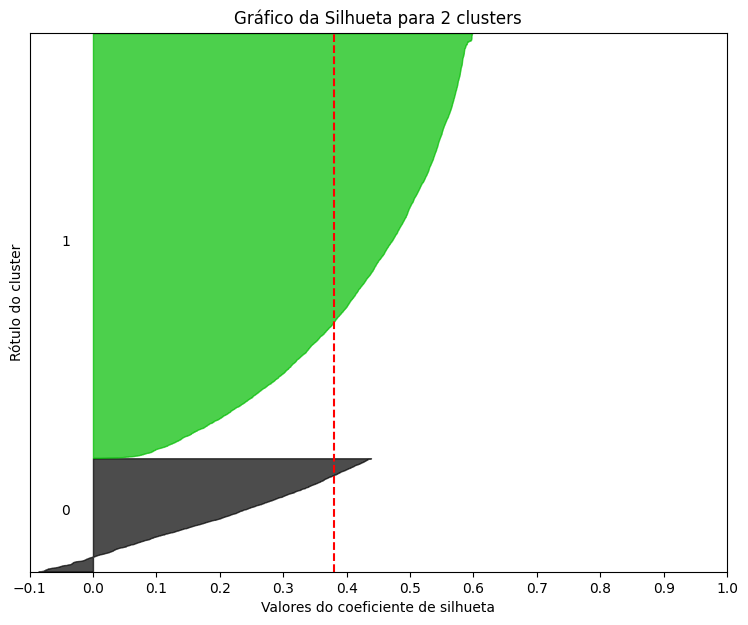

In [ ]:
graf_silhueta(n_clusters=2, dados=dados)

>  Com isso, percebemos de maneira aprofundada que o melhor resultado ainda não é bom. Isso pode indicar que o problema não está na inicialização de clusters que definimos, mas sim numa questão que seria resolvida ajustando os dados.

#Outra visualização(método cotovelo)

In [ ]:
def plot_cotovelo(inercia):
    plt.figure(figsize=(8,4))
    plt.plot(range(2,21),inercia,'bo-')
    plt.xlabel('Número de clusters')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo para Determinação de k')
    plt.show()

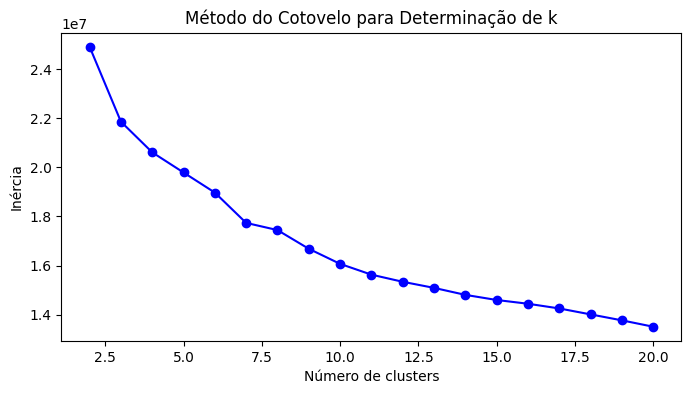

In [ ]:
plot_cotovelo(inercia)

> O gráfico em azul mostra os pontos bem marcados. No topo do eixo y, observamos o valor 1e7, informando que todos os valores foram multiplicados por 10⁷. Isso indica que a inércia é muito alta.

Embora os valores decaiam com o aumento da quantidade de clusters conforme esperado, ainda são elevados. Não encontramos um ponto de quebra representando o "cotovelo" — isso indica que, independentemente dos valores de cluster, o desempenho do modelo não melhora.

#Ajustando os Dados para o k-means

In [ ]:
dados.describe()

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
count,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,...,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000
mean,26.852679,31.283790,3.063424,2.927186,2.536946,1.836515,1.641010,1.548645,1.207666,1.198430,...,1.340055,2.977986,4.094828,1.720289,0.819735,0.589594,1.050647,0.761469,0.166256,0.072275
std,1.203746,35.891178,8.374443,7.431099,9.810703,7.881526,6.818708,5.862203,5.376673,5.558905,...,4.934874,7.479126,7.670547,5.092112,3.799795,2.999547,4.492218,0.426202,0.372325,0.258953
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,27.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,28.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,30.000000,605.000000,220.000000,90.000000,220.000000,170.000000,140.000000,310.000000,80.000000,140.000000,...,70.000000,120.000000,110.000000,80.000000,80.000000,80.000000,80.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

dados_escalados = scaler.fit_transform(dados)
dados_escalados

array([[0.66666667, 0.08099174, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.66666667, 0.0677686 , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.55555556, 0.00165289, 0.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.66666667, 0.05289256, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.66666667, 0.03305785, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.44444444, 0.04132231, 0.        , ..., 1.        , 0.        ,
        0.        ]])

In [ ]:
dados_escalados = pd.DataFrame(dados_escalados, columns=dados.columns)
dados_escalados.describe()

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
count,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,...,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000
mean,0.650298,0.051709,0.013925,0.032524,0.011532,0.010803,0.011721,0.004996,0.015096,0.008560,...,0.019144,0.024817,0.037226,0.021504,0.010247,0.007370,0.013133,0.761469,0.166256,0.072275
std,0.133750,0.059324,0.038066,0.082568,0.044594,0.046362,0.048705,0.018910,0.067208,0.039706,...,0.070498,0.062326,0.069732,0.063651,0.047497,0.037494,0.056153,0.426202,0.372325,0.258953
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.555556,0.008264,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.666667,0.034711,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.777778,0.074380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

#Verificando métricas para os dados escalados

In [ ]:
silhueta, inercia = avaliar(dados_escalados)
silhueta

['k=2 - 0.6684575483061145',
 'k=3 - 0.744750087531752',
 'k=4 - 0.3053068053389539',
 'k=5 - 0.30744468106290657',
 'k=6 - 0.3112387030023554',
 'k=7 - 0.3085860859611098',
 'k=8 - 0.319777962428703',
 'k=9 - 0.22706218374995074',
 'k=10 - 0.22472400849594523',
 'k=11 - 0.22798574383673695',
 'k=12 - 0.22555027549760792',
 'k=13 - 0.16185795333037284',
 'k=14 - 0.16298650173075177',
 'k=15 - 0.165522543693859',
 'k=16 - 0.16673895280846962',
 'k=17 - 0.1638428224739627',
 'k=18 - 0.1652194328832505',
 'k=19 - 0.16528102868680855',
 'k=20 - 0.15001075044221607']

Valor médio para 3 clusters: 0.745


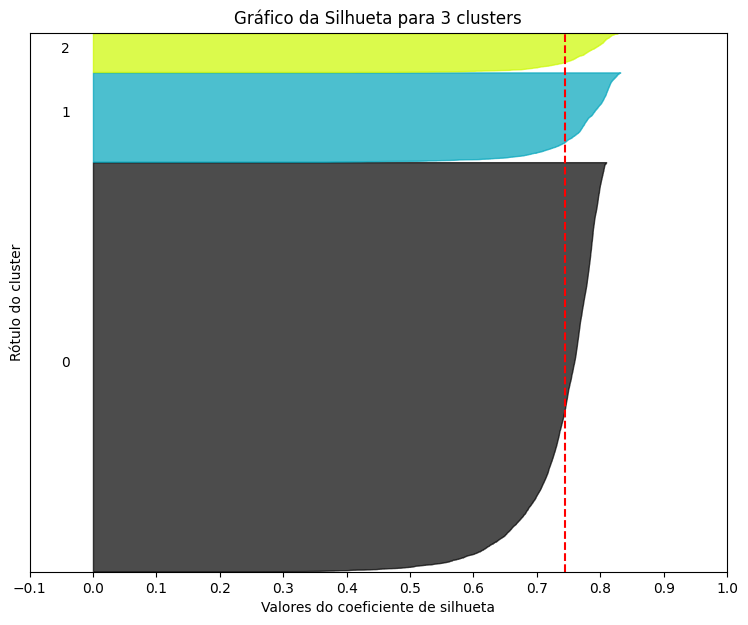

In [ ]:
graf_silhueta(n_clusters=3, dados=dados_escalados)

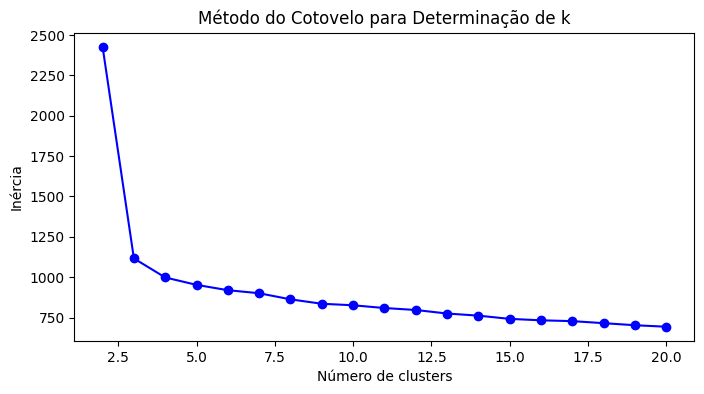

In [ ]:
plot_cotovelo(inercia)

#Otimizando a Precisão do Modelo

In [ ]:
modelo_kmeans = KMeans(n_clusters=3, random_state=45, n_init='auto')
modelo_kmeans.fit(dados_escalados)

KMeans(n_clusters=3, random_state=45)

In [ ]:
joblib.dump(modelo_kmeans, 'kmeans.pkl')

['kmeans.pkl']

#Analisando as informações de cada cluster

In [ ]:
dados_analise = pd.DataFrame()

dados_analise[dados_escalados.columns] = scaler.inverse_transform(dados_escalados)

dados_analise

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
0,27.0,49.0,0.0,0.0,10.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,1.0,0.0,0.0
1,27.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,0.0,10.0,0.0,0.0,0.0,0.0,10.0,1.0,0.0,0.0
2,26.0,1.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,30.0,0.0,0.0,0.0,1.0,0.0,0.0
3,28.0,32.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,28.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12987,26.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20.0,0.0,0.0,0.0,1.0,0.0,0.0
12988,26.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12989,27.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12990,27.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
dados_analise['cluster'] = modelo_kmeans.labels_

In [ ]:
cluster_media = dados_analise.groupby('cluster').mean()
cluster_media.T #Transpose(Transforma linhas em colunas)

cluster,0,1,2
idade,26.787830,27.031944,27.123536
numero_de_amigos,32.382796,26.173611,31.460064
basquete,2.959668,3.763889,2.545261
futebol_americano,2.462347,5.347222,2.257721
futebol,2.567472,2.592593,2.087327
softbol,2.273325,0.097222,1.235357
voleibol,1.935712,0.453704,1.267306
natacao,1.693116,0.976852,1.341853
animacao,1.441423,0.092593,1.309904
beisebol,0.792480,3.231481,0.798722


In [ ]:
cluster_media = cluster_media.transpose()

cluster_media.columns = [0,1,2]

In [ ]:
cluster_media

,0,1,2
idade,26.787830,27.031944,27.123536
numero_de_amigos,32.382796,26.173611,31.460064
basquete,2.959668,3.763889,2.545261
futebol_americano,2.462347,5.347222,2.257721
futebol,2.567472,2.592593,2.087327
softbol,2.273325,0.097222,1.235357
voleibol,1.935712,0.453704,1.267306
natacao,1.693116,0.976852,1.341853
animacao,1.441423,0.092593,1.309904
beisebol,0.792480,3.231481,0.798722


#Descrevendo os agrupamentos

In [ ]:
cluster_media[0].sort_values(ascending=False)

,0
numero_de_amigos,32.382796
idade,26.787830
musica,8.541393
cabelo,5.626200
danca,5.463459
compras,4.943900
fofo,4.413221
banda,3.368038
shopping,3.260892
basquete,2.959668


In [ ]:
cluster_media[1].sort_values(ascending=False)

,1
idade,27.031944
numero_de_amigos,26.173611
musica,8.180556
futebol_americano,5.347222
banda,4.120370
basquete,3.763889
beisebol,3.231481
rock,3.148148
futebol,2.592593
danca,2.578704


In [ ]:
cluster_media[2].sort_values(ascending=False)

,2
numero_de_amigos,31.460064
idade,27.123536
musica,7.103301
danca,4.749734
cabelo,4.345048
fofo,3.642173
compras,3.365282
shopping,3.045793
banda,2.758253
basquete,2.545261


### Visualização do Impacto das Variáveis por Cluster
Vamos plotar as variáveis de interesse (excluindo idade e gênero) para ver quais definem melhor a separação dos grupos.

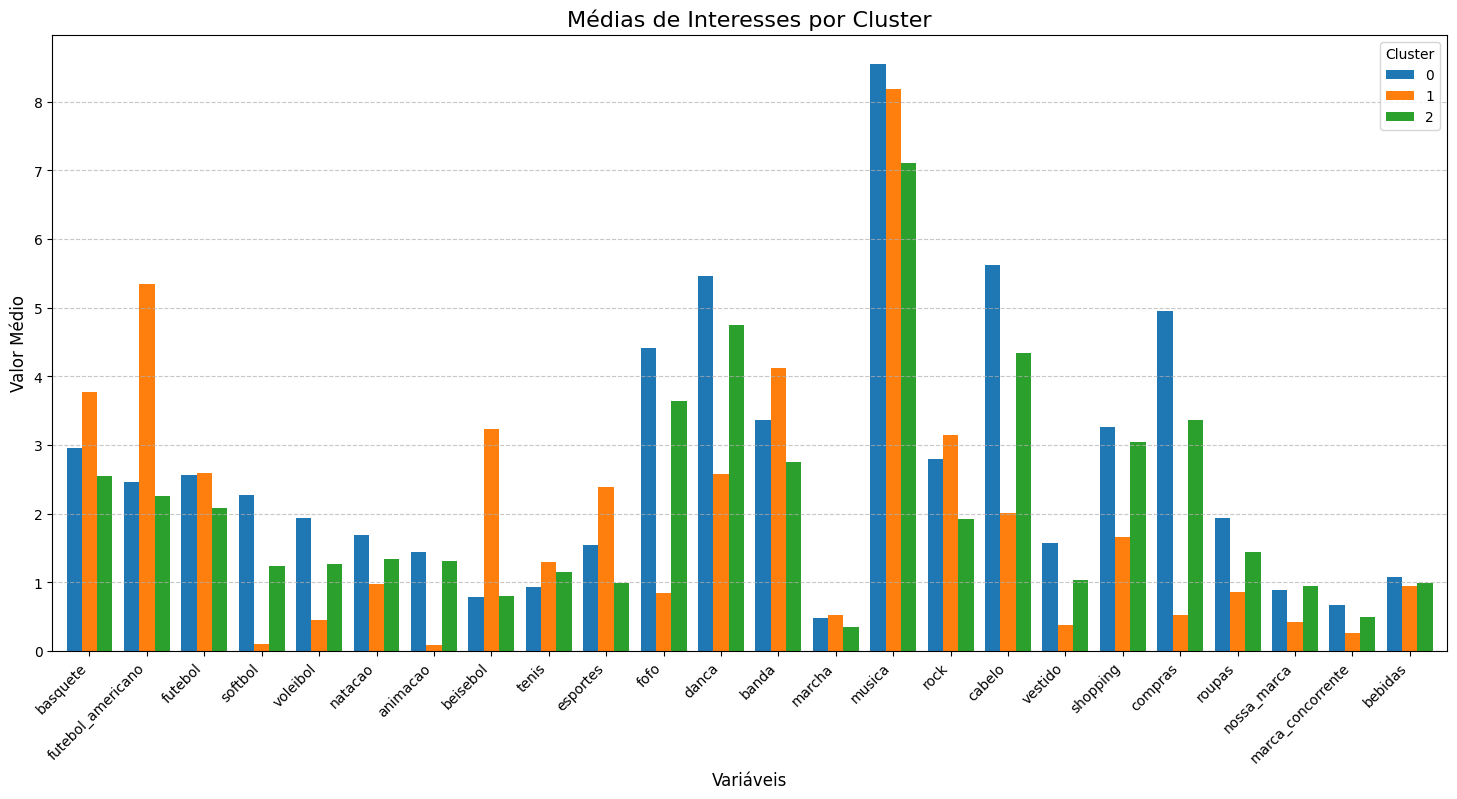

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas de interesses (removendo idade, amigos e sexo)
colunas_interesses = [col for col in cluster_media.index if col not in ['idade', 'numero_de_amigos', 'sexo_F', 'sexo_M', 'sexo_NE']]

# Plotando o gráfico de barras comparativo
cluster_media.loc[colunas_interesses].plot(kind='bar', figsize=(18, 8), width=0.8)
plt.title('Médias de Interesses por Cluster', fontsize=16)
plt.xlabel('Variáveis', fontsize=12)
plt.ylabel('Valor Médio', fontsize=12)
plt.legend(title='Cluster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

#Relatório Final de Observações e Alternativas

 1. Diagnóstico do Modelo K-Means
Após a normalização dos dados e o treinamento do modelo com $k=3$, observamos os seguintes pontos críticos:
* **Impacto do Gênero:** O algoritmo utilizou o gênero como a principal característica de separação. O **Cluster 0** tornou-se exclusivamente feminino, o **Cluster 1** exclusivamente masculino e o **Cluster 2** agrupou casos sem gênero especificado (NE). Isso indica que a variância do gênero 'ofuscou' padrões de interesse mais sutis.
* **Esparsidade:** A grande quantidade de valores zero nos interesses específicos resultou em correlações baixas e inércia elevada. O modelo tendeu a agrupar pessoas pela 'ausência' de interesses comuns em vez da presença de afinidades específicas.
* **Métricas:** Embora o Silhouette Score tenha atingido um valor alto (~0.74), ele reflete a separação perfeita por gênero, e não necessariamente uma segmentação comportamental rica em termos de interesses de marketing.

 2. Estratégias para Redução de Viés
Para evitar que o modelo seja apenas um 'classificador de gênero', discutimos as seguintes abordagens:
* **Remoção de Variáveis de Controle:** Treinar o modelo sem as colunas de sexo para forçar a descoberta de clusters baseados puramente em interesses.
* **Engenharia de Features:** Agrupar interesses em categorias macro (ex: combinar esportes individuais e coletivos) para reduzir a esparsidade.
* **Redução de Dimensionalidade (PCA):** Utilizar componentes principais para filtrar o ruído e focar nas combinações de variáveis que explicam a maior parte da variância.

3. Alternativas de Modelagem e Normalização
Para cenários futuros com dados similares:
* **StandardScaler:** Pode ser mais eficaz que o MinMaxScaler para destacar desvios da média em perfis de interesse.
* **TF-IDF:** Transformar as contagens de interesses para dar mais peso a termos raros e específicos, similar ao processamento de texto.
* **DBSCAN:** Experimentar algoritmos baseados em densidade para identificar grupos de usuários altamente ativos, separando-os do 'ruído' de usuários com poucas interações.
* **Similaridade de Cosseno:** Utilizar métricas de distância que ignorem a magnitude absoluta e foquem na proporção do perfil de interesses.

# Advantages and disadvantages of k-means(https://developers.google.com/machine-learning/clustering/kmeans/advantages-disadvantages?hl=pt-br)

K-means is useful and efficient in many machine learning contexts, but has
some distinct weaknesses.

## Advantages of k-means

Relatively simple to implement.

Scales to large data sets.

Always converges.

Allows warm-starting the positions of centroids.

Smoothly adapts to new examples.

Can be generalized to clusters of different shapes and sizes, such as elliptical clusters.

### Generalizing k-means

A straightforward implementation of k-means can struggle with clusters of
different densities and sizes. The left side of Figure 1 shows the clusters
we'd expect to see, while the right side shows the clusters proposed by k-means.
![Two graphs side-by-side. The first showing a dataset with somewhat obvious clusters. The second showing an odd grouping of examples after running k-means.](https://developers.google.com/machine-learning/clustering/images/Generalization.svg) **Figure 1: Ungeneralized k-means example.**

For better performance on imbalanced clusters like the ones shown in Figure 1,
you can generalize, that is, adapt, k-means. Figure 2 shows three different
datasets clustered with two different generalizations. The first dataset shows
k-means without generalization, while the second and third allow for clusters to
vary in width.
![Three graphs showing k-means without generalization, then k-means
allowing for varying widths, then k-means allowing for varying widths
across dimensions.](https://developers.google.com/machine-learning/clustering/images/KmeansGeneralization.svg) **Figure 2: k-means clustering with and without generalization.**

This course doesn't cover how to generalize k-means, but those interested
should see [Clustering -- k-means Gaussian mixture
models](http://www.cs.cmu.edu/%7Eguestrin/Class/10701-S07/Slides/clustering.pdf)
by Carlos Guestrin from Carnegie Mellon University.

## Disadvantages of k-means

\\(k\\) must be chosen manually.

Results depend on initial values.

For low \\(k\\), you can mitigate this dependence by running k-means several
times with different initial values and picking the best result. As \\(k\\)
increases, you need **k-means seeding** to pick better initial
centroids For a full discussion of k-means seeding, see
["A Comparative
Study of Efficient Initialization Methods for the K-means Clustering
Algorithm,"](https://arxiv.org/abs/1209.1960) by M. Emre Celebi, Hassan A. Kingravi, and Patricio A. Vela.

Difficulty clustering data of varying sizes and densities without generalization.

Difficulty clustering outliers.

Centroids can be dragged by outliers, or outliers might get their own cluster
instead of being ignored. Consider removing or clipping outliers before
clustering.

Difficulty scaling with number of dimensions.

As the number of dimensions in the data increases, a distance-based similarity
measure converges to a constant value between any given examples. Reduce
dimensionality either by using
[**PCA**](https://wikipedia.org/wiki/Principal_component_analysis)
on the feature data or by using **spectral clustering** to modify the clustering
algorithm.

### Curse of dimensionality and spectral clustering

In these three plots, notice how, as dimensions increase, the standard deviation
in distance between examples shrinks relative to the mean distance between
examples. This
convergence means that k-means becomes less effective at distinguishing between
examples as the dimensionality of the data increases. This is referred to as
the **curse of dimensionality**.
![Three plots that show how the standard deviation of distance between examples decreases as the number of dimensions increases](https://developers.google.com/machine-learning/clustering/images/CurseofDimensionality.svg) **Figure 3: A demonstration of the curse of dimensionality. Each plot shows the pairwise distances between 200 random points.**

You can avoid this diminishment in performance with **spectral clustering**,
which adds pre-clustering steps to the algorithm. To perform spectral
clustering:

1. Reduce the dimensionality of feature data by using PCA.
2. Project all data points into the lower-dimensional subspace.
3. Cluster the data in this subspace using your chosen algorithm.

See [*A Tutorial on Spectral
Clustering*](https://github.com/petermartigny/Advanced-Machine-Learning/blob/master/DataLab2/Luxburg07_tutorial_4488%5B0%5D.pdf) by Ulrike von Luxburg for more information on spectral
clustering.

> [!IMPORTANT]
> **Key terms:**
>
> <br />
>
> - spectral clustering
>
> <br />
>